<a href="https://colab.research.google.com/github/e23191-eng/Statistical-Learning-e23191-/blob/main/assignment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment07-KALMAN FILTER**
# Answers

# Q. Analytical Derivation

# **ANSWER**

1.Given the linear transformation of a Gaussian vector:$$x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$$

Since $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ are independent Gaussian random variables, their linear combination is also Gaussian.

Mean ($m_k^-$):$$m_k^- = \mathbb{E}[x^{-}_k] = \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}]$$

Using the linearity of expectation and noting that $\mathbb{E}[w_{k-1}] = 0$:$$
m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}] = A_{k-1}m_{k-1}$$

Covariance ($P_k^-$):$$P_k^- = \text{Var}(x^{-}_k) = \mathbb{E}[(x^{-}_k - m_k^-)(x^{-}_k - m_k^-)^T]$$$$P_k^- = \mathbb{E}[(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1})(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1})^T]$$

Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent, their cross-covariance terms are zero:$$P_k^- = A_{k-1}\mathbb{E}[(x^{+}_{k-1} - m_{k-1})(x^{+}_{k-1} - m_{k-1})^T]A_{k-1}^T + G_{k-1}\mathbb{E}[w_{k-1}w_{k-1}^T]G_{k-1}^T$$$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

2.Given the measurement model:$$y^{-}_k = H_k x^{-}_k + z_k$$

where $z_k \sim \mathscr{N}(0, \Sigma_m)$ is independent of $x^{-}_k$.Mean:$$\mathbb{E}[y^{-}_k] = \mathbb{E}[H_k x^{-}_k + z_k] = H_k \mathbb{E}[x^{-}_k] + \mathbb{E}[z_k] = H_k m_k^-$$Covariance:$$\text{Var}(y^{-}_k) = \text{Var}(H_k x^{-}_k + z_k)$$

Since $x^{-}_k$ and $z_k$ are independent:$$\text{Var}(y^{-}_k) = H_k \text{Var}(x^{-}_k)H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$

3. Joint Distribution proof

The joint vector $\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix}$ is a linear transformation of the independent Gaussian vectors $x_k^-$ and $z_k$:$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} = \begin{bmatrix} I \\ H_k \end{bmatrix} x_k^- + \begin{bmatrix} 0 \\ I \end{bmatrix} z_k$$

The mean is trivially $\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$.

For the covariance matrix, we find the cross-covariance term:

$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T]$$$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T]$$$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$

Since $x_k^-$ and $z_k$ are independent, the second term vanishes, leaving:$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$

Symmetrically, $\text{Cov}(y_k^-, x_k^-) = H_k P_k^-$. Thus:$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

4 & 5. Conditional Distribution Properties

Using the Gaussian Conditioning Theorem,

 if $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix}\right)$,

 then:$$\mathbb{E}[X \mid Y = y] = \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y - \mu_y)$$$$\text{Var}(X \mid Y = y) = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}$$

 Substituting our joint distribution parameters where $X = x_k^-$ and $Y = y_k^-$:$$K_k \triangleq \Sigma_{xy}\Sigma_{yy}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

 Answer to Question 5 (and proof for 4):$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

# **Answer**

By applying the scalar values ($A_{k-1}=a$, $G_{k-1}=1$, $\Sigma_p=q$, $H_k=h$, $\Sigma_m=r$) to the general equations derived in the first section:

1.$m_k^- = a\,m_{k-1}$ and $P_k^- = a^2 P_{k-1} + q$ (Direct scalar substitution).

2.$K_k = \frac{P_k^- h}{h^2 P_k^- + r} = \frac{P_k^- h}{S_k}$. Hence $m_k = m_k^- + K_k(y_k^{\text{obs}} - hm_k^-)$ and $P_k = (1-K_k h)P_k^-$.

3.Prior to seeing $y_k$, the distribution depends entirely on $Y_{k-1}$, matching the predictive measurement distribution formula: $\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$.

4.After conditioning on $y_k$, the updated state distribution mean is $m_k$ and covariance is $P_k$. Passing this updated state through the observation model gives: $\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr)$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# Parameters
np.random.seed(42)
a = 0.95
q = 0.5
h = 1.0
r = 1.0
T = 30

# Initialize tracks
m = 0.0
P = 2.0
true_x = 0.0

states_true = []
measurements = []
means_prior = []
vars_prior = []
means_post = []
vars_post = []

# Simulate and Filter
for k in range(T):
    # True state transition & measurement generation
    true_x = a * true_x + np.random.normal(0, np.sqrt(q))
    y_obs = h * true_x + np.random.normal(0, np.sqrt(r))

    # Kalman Filter Predict
    m_minus = a * m
    P_minus = a**2 * P + q

    # Kalman Filter Update
    S = h**2 * P_minus + r
    K = (P_minus * h) / S
    m = m_minus + K * (y_obs - h * m_minus)
    P = (1 - K * h) * P_minus

    # Save parameters for plotting
    states_true.append(true_x)
    measurements.append(y_obs)
    means_prior.append(m_minus)
    vars_prior.append(P_minus)
    means_post.append(m)
    vars_post.append(P)

# Animation Setup
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-10, 10, 500)

line_prior, = ax.plot([], [], 'r-', label='Prior PDF $p(x_k | Y_{k-1})$', lw=2)
line_post, = ax.plot([], [], 'b-', label='Posterior PDF $p(x_k | Y_k)$', lw=2)
vline_true = ax.axvline(0, color='g', linestyle='--', label='True State $x_k$')
vline_meas = ax.axvline(0, color='k', linestyle=':', label='Measured $y_k$')

ax.set_xlim(-8, 8)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right')
ax.set_title("Kalman Filter 1D Distributions Evolution")
ax.set_xlabel("State Space")
ax.set_ylabel("Probability Density")

def update(frame):
    pdf_prior = norm.pdf(x_axis, means_prior[frame], np.sqrt(vars_prior[frame]))
    pdf_post = norm.pdf(x_axis, means_post[frame], np.sqrt(vars_post[frame]))

    line_prior.set_data(x_axis, pdf_prior)
    line_post.set_data(x_axis, pdf_post)
    vline_true.set_xdata([states_true[frame]])
    vline_meas.set_xdata([measurements[frame]])
    ax.set_title(f"Time Step k = {frame+1}/{T}")
    return line_prior, line_post, vline_true, vline_meas

ani = FuncAnimation(fig, update, frames=T, blit=True, interval=600)
plt.close()
HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

# **Answer**

## Part A

Using Newtonian kinematics equations for a constant-velocity framework with time increment $\Delta t$:$$p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x(k-1)\Delta t^2$$$$v_x(k) = v_x(k-1) + a_x(k-1)\Delta t$$Assuming acceleration acts purely as white noise perturbations $w_{k-1} = \begin{bmatrix} a_x \\ a_y \end{bmatrix}$:

1. Matrix $A$ & $G$ Expression:$$\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix} + \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$This clearly yields the structured matrices:$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \quad G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

2. Matrix $H$ Expression:Since the measurement vector isolates only positions $p_x$ and $p_y$:$$y_k = \begin{bmatrix} p_x^{\text{meas}}(k) \\ p_y^{\text{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} + z_k$$$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

## Part B

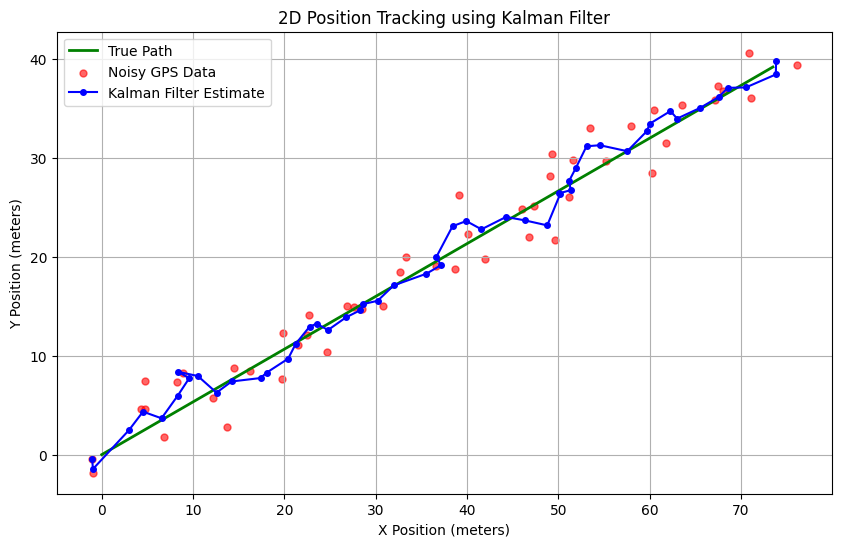

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def kalman_filter_2d(gps_measurements, dt=1.0):
    # Transition Matrices Initialization
    A = np.array([
        [1, 0, dt,  0],
        [0, 1,  0, dt],
        [0, 0,  1,  0],
        [0, 0,  0,  1]
    ])

    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    G = np.array([
        [0.5 * dt**2, 0],
        [0, 0.5 * dt**2],
        [dt, 0],
        [0, dt]
    ])

    # Noise Covariances
    Sigma_p = np.eye(2) * 0.1   # Process noise covariance
    Sigma_m = np.eye(2) * 5.0   # GPS Measurement Noise covariance

    Q = G @ Sigma_p @ G.T
    R = Sigma_m

    # Initial State Estimations
    x = np.array([gps_measurements[0, 0], gps_measurements[0, 1], 0.0, 0.0])
    P = np.eye(4) * 10.0

    filtered_states = []

    for y_obs in gps_measurements:
        # Predict Step
        x_minus = A @ x
        P_minus = A @ P @ A.T + Q

        # Update Step
        S = H @ P_minus @ H.T + R
        K = P_minus @ H.T @ np.linalg.inv(S)

        x = x_minus + K @ (y_obs - H @ x_minus)
        P = (np.eye(4) - K @ H) @ P_minus

        filtered_states.append(x.copy())

    return np.array(filtered_states)

# Generate Mock Trajectory Data
num_steps = 50
true_vel = np.array([1.5, 0.8])
true_positions = np.array([[i * true_vel[0], i * true_vel[1]] for i in range(num_steps)])
noisy_gps = true_positions + np.random.normal(0, 2.2, size=true_positions.shape)

# Run Filter
estimates = kalman_filter_2d(noisy_gps, dt=1.0)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(true_positions[:, 0], true_positions[:, 1], 'g-', label='True Path', lw=2)
plt.scatter(noisy_gps[:, 0], noisy_gps[:, 1], color='red', alpha=0.6, label='Noisy GPS Data', s=25)
plt.plot(estimates[:, 0], estimates[:, 1], 'b-o', label='Kalman Filter Estimate', markersize=4)
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.title('2D Position Tracking using Kalman Filter')
plt.legend()
plt.grid(True)
plt.show()